# Single-Day LOB Feature Distributions

Build one day of L2/order-book features from raw MBO, add future as-of price labels, then plot distributions and QQ plots.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from statistics import NormalDist

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from tools.data import RAW_PATH
from tools.features import LOBFeatures, depth_meta, mbo_to_features
from tools.price import add_executable_return, add_return

In [2]:
# Data
DAY = "2026-05-05"
PROD = "ES"
L2_DEPTH = 5
BATCH_SIZE = 65_536
REQUIRE_VALID_TOP = True

# Feature knobs
IMBALANCE_DEPTHS = [1, 3, 5]
IMBALANCE_LOG = False
WEIGHTED_PRICE_DEPTH = 5
WEIGHTED_PRICE_SIZES = [10, 25, 50]
TRADE_MOMENTUM_HALF_LIVES = ['1s', '10s', '1m']

# Future label knobs
FUTURE_HORIZONS = ["1s", "5s", "15s"]
FUTURE_WEIGHTS = [0.5, 0.3, 0.2]
EXECUTABLE_SIZE = 25
EXECUTABLE_DEPTH = 5

# Plot knobs
PLOT_COLUMNS = None  # or set an explicit list[str]
PLOT_SAMPLE_N = 200_000
QQ_SAMPLE_N = 20_000
RNG_SEED = 7

assert L2_DEPTH >= max([*IMBALANCE_DEPTHS, WEIGHTED_PRICE_DEPTH, EXECUTABLE_DEPTH])

In [3]:
def raw_path(day: str, prod: str) -> Path:
    path = Path(
        RAW_PATH.format(
            prod=prod,
            prod_s=prod.lower(),
            d=day,
            dnd=day.replace("-", ""),
            dslash=day.replace("-", "/"),
            tag="*",
        )
    )
    matches = sorted(path.parent.glob(path.name))
    if len(matches) != 1:
        raise ValueError(f"expected one file for {day=} {prod=}, matched {matches}")
    return matches[0]


def tag(x: object) -> str:
    return str(x).replace(".", "p")


def feature_exprs() -> dict[str, pl.Expr]:
    exprs = {}
    for depth in IMBALANCE_DEPTHS:
        exprs[f"imb_d{depth}"] = LOBFeatures.book_imbalance(depth, log=IMBALANCE_LOG)
    for size in sorted(set([*WEIGHTED_PRICE_SIZES, EXECUTABLE_SIZE])):
        exprs[f"weighted_price_sz{tag(size)}"] = LOBFeatures.size_weighted_avg_price(WEIGHTED_PRICE_DEPTH, size)
    for half_life in TRADE_MOMENTUM_HALF_LIVES:
        exprs[f"trade_momentum_hl{tag(half_life)}"] = LOBFeatures.trade_momentum(half_life)
    return exprs


path = raw_path(DAY, PROD)
exprs = feature_exprs()
current_exec_col = f"weighted_price_sz{tag(EXECUTABLE_SIZE)}"
path

PosixPath('/home/jli/projects/rep/data/databento_glbx_mdp3_mbo_full_day_parquet/ESM6_2026-05-05_normal_es_full_day.parquet')

In [4]:
meta_cols = ["ts_event", "ts_recv", "symbol", *depth_meta(L2_DEPTH)]
batches = mbo_to_features(
    str(path),
    exprs,
    l2_depth=L2_DEPTH,
    meta_cols=meta_cols,
    batch_size=BATCH_SIZE,
)

df = pl.concat(list(batches), how="vertical_relaxed")
if REQUIRE_VALID_TOP:
    df = df.filter((pl.col("bid_px_0") != 9_223_372_036_854_775_807) & (pl.col("ask_px_0") != 9_223_372_036_854_775_807))
df = df.sort(["publisher_id", "instrument_id", "ts_event", "row_nr"])
df = df.with_columns(((pl.col("bid_px_0") + pl.col("ask_px_0")) / 2).alias("mid"))
df.head()

ts_event,ts_recv,symbol,row_nr,sequence,publisher_id,instrument_id,trade_px,trade_sz,trade_side,bid_px_0,bid_sz_0,bid_ct_0,ask_px_0,ask_sz_0,ask_ct_0,bid_px_1,bid_sz_1,bid_ct_1,ask_px_1,ask_sz_1,ask_ct_1,bid_px_2,bid_sz_2,bid_ct_2,ask_px_2,ask_sz_2,ask_ct_2,bid_px_3,bid_sz_3,bid_ct_3,ask_px_3,ask_sz_3,ask_ct_3,bid_px_4,bid_sz_4,bid_ct_4,ask_px_4,ask_sz_4,ask_ct_4,imb_d1,imb_d3,imb_d5,weighted_price_sz10,weighted_price_sz25,weighted_price_sz50,trade_momentum_hl1s,trade_momentum_hl10s,trade_momentum_hl1m,mid
"datetime[ns, UTC]","datetime[ns, UTC]",str,u64,u32,u16,u32,i64,u32,u8,i64,u64,u32,i64,u64,u32,i64,u64,u32,i64,u64,u32,i64,u64,u32,i64,u64,u32,i64,u64,u32,i64,u64,u32,i64,u64,u32,i64,u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-05-03 12:00:05.537292457 UTC,2026-05-05 00:00:00 UTC,"""ESM6""",1540,698,1,42140864,null,null,null,7199250000000,2,2,7282000000000,1,1,7199000000000,4,1,9223372036854775807,0,0,7198750000000,7,2,9223372036854775807,0,0,7198500000000,6,1,9223372036854775807,0,0,7198250000000,8,2,9223372036854775807,0,0,1.0,11.892394,25.596778,7.2405e12,7.2403e12,7.2403e12,0.0,0.0,0.0,7.2406e12
2026-05-03 12:00:05.537292457 UTC,2026-05-05 00:00:00 UTC,"""ESM6""",1541,727,1,42140864,null,null,null,7199250000000,2,2,7282000000000,36,2,7199000000000,4,1,9223372036854775807,0,0,7198750000000,7,2,9223372036854775807,0,0,7198500000000,6,1,9223372036854775807,0,0,7198250000000,8,2,9223372036854775807,0,0,-34.0,-23.107606,-9.403222,7.2405e12,7.2403e12,7.2403e12,0.0,0.0,0.0,7.2406e12
2026-05-03 12:00:05.537292457 UTC,2026-05-05 00:00:00 UTC,"""ESM6""",1542,729,1,42140864,null,null,null,7199250000000,2,2,7282000000000,36,2,7199000000000,4,1,7282250000000,2,1,7198750000000,7,2,9223372036854775807,0,0,7198500000000,6,1,9223372036854775807,0,0,7198250000000,8,2,9223372036854775807,0,0,-34.0,-25.095594,-11.39121,7.2405e12,7.2403e12,7.2403e12,0.0,0.0,0.0,7.2406e12
2026-05-03 12:00:05.537292457 UTC,2026-05-05 00:00:00 UTC,"""ESM6""",1543,698,1,42140864,null,null,null,7199250000000,2,2,7282000000000,36,2,7199000000000,4,1,7282250000000,2,1,7198750000000,7,2,7283000000000,1,1,7198500000000,6,1,9223372036854775807,0,0,7198250000000,8,2,9223372036854775807,0,0,-34.0,-26.071995,-12.367611,7.2405e12,7.2403e12,7.2403e12,0.0,0.0,0.0,7.2406e12
2026-05-03 12:00:05.537292457 UTC,2026-05-05 00:00:00 UTC,"""ESM6""",1544,698,1,42140864,null,null,null,7199250000000,2,2,7282000000000,36,2,7199000000000,4,1,7282250000000,2,1,7198750000000,7,2,7283000000000,2,2,7198500000000,6,1,9223372036854775807,0,0,7198250000000,8,2,9223372036854775807,0,0,-34.0,-27.048396,-13.344012,7.2405e12,7.2403e12,7.2403e12,0.0,0.0,0.0,7.2406e12


In [5]:
df = add_return(
    df,
    pl.col("mid"),
    FUTURE_HORIZONS,
    FUTURE_WEIGHTS,
    name="future_mid",
)
df = add_executable_return(
    df,
    EXECUTABLE_DEPTH,
    EXECUTABLE_SIZE,
    FUTURE_HORIZONS,
    FUTURE_WEIGHTS,
    name="future_executable_price",
)
df = df.with_columns(
    (pl.col("future_mid") - pl.col("mid")).alias("future_mid_change"),
    (pl.col("future_executable_price") - pl.col(current_exec_col)).alias("future_executable_change"),
)

summary_cols = [*exprs, "mid", "future_mid", "future_executable_price", "future_mid_change", "future_executable_change"]
df.select(summary_cols).describe()

statistic,imb_d1,imb_d3,imb_d5,weighted_price_sz10,weighted_price_sz25,weighted_price_sz50,trade_momentum_hl1s,trade_momentum_hl10s,trade_momentum_hl1m,mid,future_mid,future_executable_price,future_mid_change,future_executable_change
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",7.127647e6,7.127647e6,7.127647e6,7.127647e6,7.127647e6,7.127647e6,7.127647e6,7.127647e6,7.127647e6,7.127647e6,7.127356e6,7.127356e6,7.127356e6,7.127356e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,291.0,291.0,291.0,291.0
"""mean""",-0.436898,-1.170674,-1.712763,7.2763e12,7.2763e12,7.2763e12,-0.011757,-0.015403,-0.025109,7.2763e12,0.011627,0.010795,-7.2763e12,-7.2763e12
"""std""",43.260985,46.345376,46.791369,1.7350e10,1.7350e10,1.7349e10,0.690325,0.436811,0.595718,1.7351e10,0.583648,0.576589,1.7349e10,1.7348e10
"""min""",-915.0,-907.8,-908.11746,7.2211e12,7.2209e12,7.2209e12,-20.0,-20.0,-20.0,7.2196e12,-14.88248,-7.390994,-7.3199e12,-7.3200e12
"""25%""",-23.0,-25.133333,-25.949206,7.2694e12,7.2693e12,7.2693e12,-0.08849,-0.063905,-0.036187,7.2694e12,-0.205956,-0.191167,-7.2866e12,-7.2867e12
"""50%""",0.0,-0.333333,-0.565079,7.2799e12,7.2799e12,7.2799e12,0.000002,-0.003097,-0.001021,7.2799e12,0.0,0.004834,-7.2799e12,-7.2799e12
"""75%""",22.0,23.4,23.283333,7.2866e12,7.2867e12,7.2867e12,0.083773,0.056905,0.034063,7.2866e12,0.240075,0.212584,-7.2694e12,-7.2693e12
"""max""",600.0,588.866667,591.04127,7.3199e12,7.3200e12,7.3200e12,12.228114,3.076374,1.000226,7.3199e12,20.445556,20.424081,-7.2196e12,-7.2209e12


In [6]:
def finite_values(frame: pl.DataFrame, col: str, sample_n: int, seed: int) -> np.ndarray:
    x = frame.get_column(col).drop_nulls().to_numpy()
    x = x[np.isfinite(x)]
    if len(x) > sample_n:
        rng = np.random.default_rng(seed)
        x = rng.choice(x, sample_n, replace=False)
    return x


def plot_distribution_qq(frame: pl.DataFrame, cols: list[str]) -> None:
    normal = NormalDist()
    fig, axes = plt.subplots(len(cols), 2, figsize=(12, 3.2 * len(cols)))
    axes = np.atleast_2d(axes)

    for i, col in enumerate(cols):
        x = finite_values(frame, col, PLOT_SAMPLE_N, RNG_SEED + i)
        axes[i, 0].hist(x, bins=100, density=True, alpha=0.8)
        axes[i, 0].set_title(f"{col} distribution")

        q = finite_values(frame, col, QQ_SAMPLE_N, RNG_SEED + 10_000 + i)
        q = q[np.isfinite(q)]
        if len(q) > 1 and q.std() > 0:
            z = np.sort((q - q.mean()) / q.std())
            p = (np.arange(1, len(z) + 1) - 0.5) / len(z)
            theory = np.array([normal.inv_cdf(float(v)) for v in p])
            axes[i, 1].scatter(theory, z, s=3, alpha=0.35)
            lo, hi = min(theory[0], z[0]), max(theory[-1], z[-1])
            axes[i, 1].plot([lo, hi], [lo, hi], color="black", linewidth=1)
        axes[i, 1].set_title(f"{col} QQ vs normal")

    fig.suptitle(f"{PROD} {DAY}", y=1.0)
    fig.tight_layout()
    plt.show()

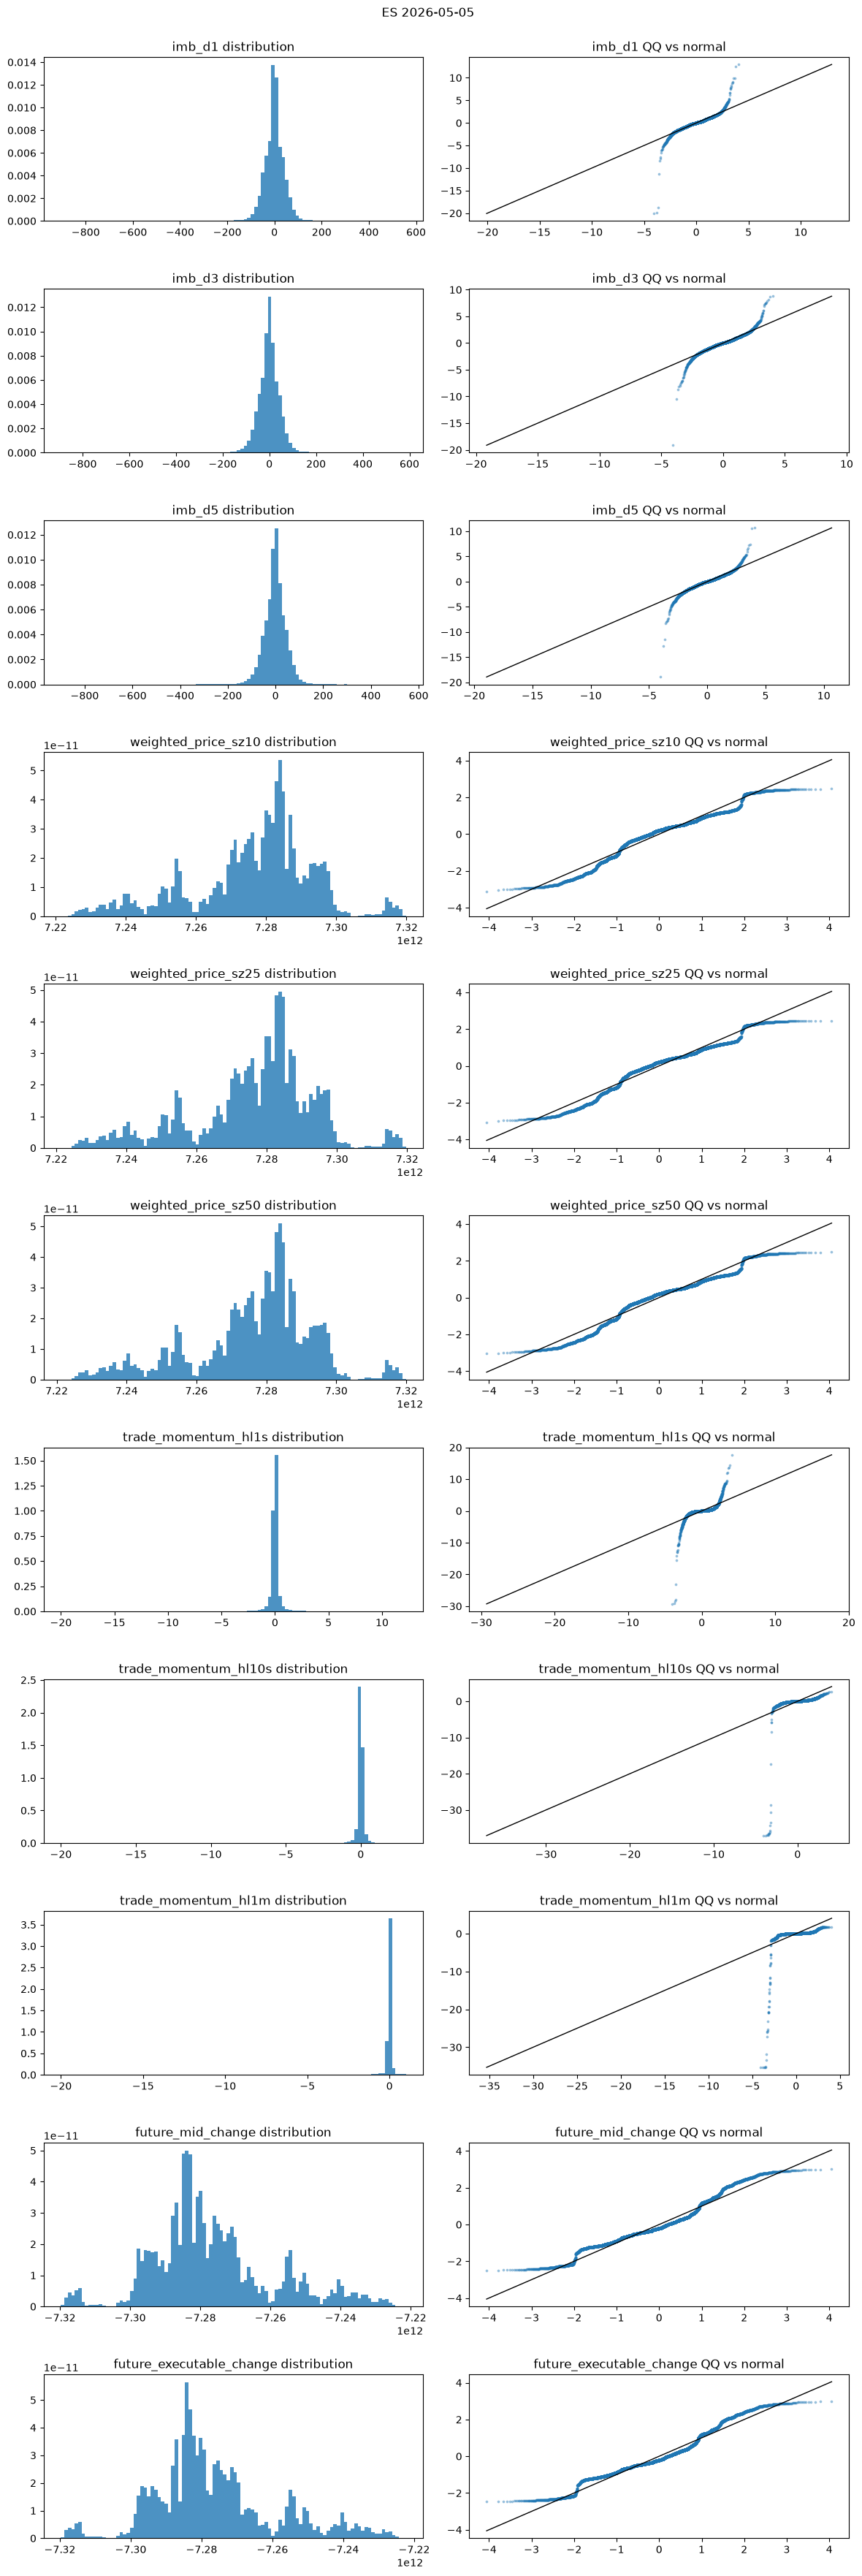

In [7]:
plot_cols = PLOT_COLUMNS or [
    *exprs.keys(),
    "future_mid_change",
    "future_executable_change",
]
plot_cols = [c for c in plot_cols if c in df.columns]
plot_distribution_qq(df, plot_cols)